In [1]:
import numpy as np
import modPlotWRF as wrf
import importlib 

## This an example for wrfout p

In [2]:
# open input file
df,dx,nx,ny,nz = wrf.loadWRF('wrfout_d01_2024-09-03_15:00:00')
df

A-grid dim (dx,nx,ny,nz) for wrfout_d01_2024-09-03_15:00:00 are (np.float32(9000.0), 740, 495, 30)
dx,nx,ny,nz are: (np.float32(9000.0), 740, 495, 30)


<xarray.Dataset> Size: 878MB
Dimensions:                (Time: 1, south_north: 495, west_east: 740,
                            bottom_top: 30, bottom_top_stag: 31,
                            soil_layers_stag: 5, west_east_stag: 741,
                            south_north_stag: 496, seed_dim_stag: 2)
Coordinates:
    XTIME                  (Time) datetime64[ns] 8B 2024-09-03T15:00:00
    XLAT                   (Time, south_north, west_east) float32 1MB -4.265 ...
    XLONG                  (Time, south_north, west_east) float32 1MB 93.89 ....
    XLAT_V                 (Time, south_north_stag, west_east) float32 1MB -4...
    XLONG_V                (Time, south_north_stag, west_east) float32 1MB 93...
    XLAT_U                 (Time, south_north, west_east_stag) float32 1MB -4...
    XLONG_U                (Time, south_north, west_east_stag) float32 1MB 93...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/168)
    Times                  (Time) |S19 19B b'2024-09-03_15:00:00'
    LU_INDEX               (Time, south_north, west_east) float32 1MB 17.0 .....
    ZNU                    (Time, bottom_top) float32 120B 0.9382 ... 0.004347
    ZNW                    (Time, bottom_top_stag) float32 124B 1.0 ... 0.0
    ZS                     (Time, soil_layers_stag) float32 20B 0.005 ... 0.23
    DZS                    (Time, soil_layers_stag) float32 20B 0.01 ... 0.16
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 1MB 0.0 ......
    PC                     (Time, south_north, west_east) float32 1MB 0.0 ......
    LANDMASK               (Time, south_north, west_east) float32 1MB 0.0 ......
    LAKEMASK               (Time, south_north, west_east) float32 1MB 0.0 ......
    SST                    (Time, south_north, west_east) float32 1MB 301.5 ....
    SST_INPUT              (Time, south_north, west_east) float32 1MB 0.0 ......
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2024-09-02_00:00:00
    SIMULATION_START_DATE:           2024-09-02_00:00:00
    WEST-EAST_GRID_DIMENSION:        741
    SOUTH-NORTH_GRID_DIMENSION:      496
    BOTTOM-TOP_GRID_DIMENSION:       31
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [4]:
# create an object for WRF 3D variables
p3d = wrf.var3D(nz=30,ny=495,nx=740,dx=9)
p3d.__dict__

{'nx': 740, 'ny': 495, 'nz': 30, 'nx1': 741, 'ny1': 496, 'nz1': 31, 'dx': 9}

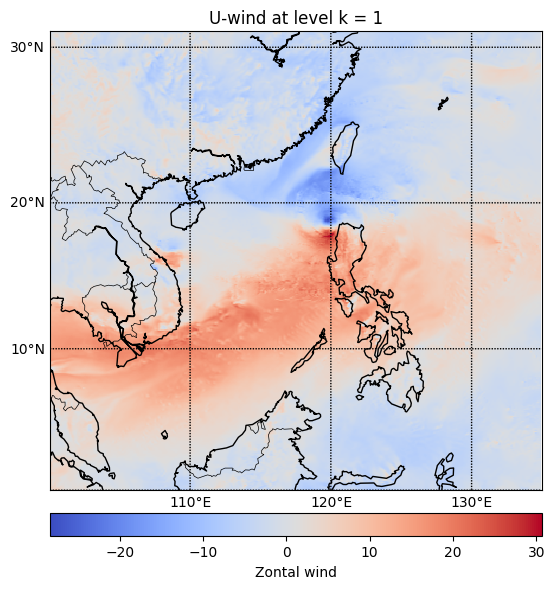

In [7]:
# plot u
u2 = p3d.shiftU3D(df.U.values)
p3d.plot_shading_world3D(df,u2,ilev=1,
                             slat=0,elat=31,slon=100,elon=135,
                             title="U-wind",
                             clevs=[0], # default color levels and scheme                          
                             #clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
                             minc=(0,0.5,0),maxc=(0,0.9,0), # my own color scheme
                             labels="Zontal wind")

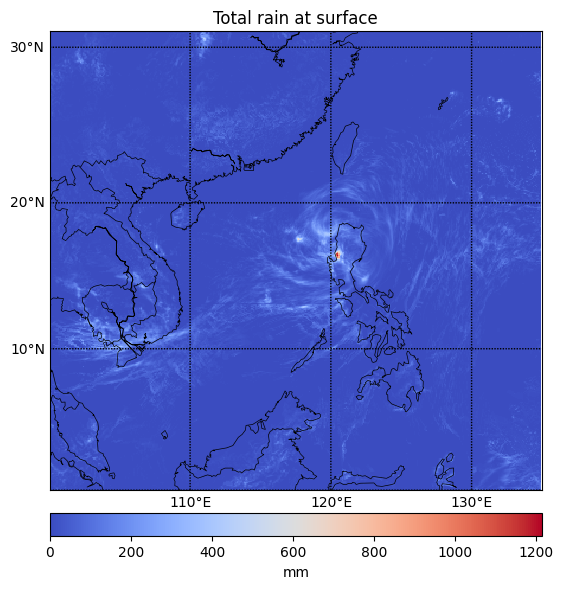

In [17]:
# plot 2D total rain
importlib.reload(wrf)
p2d = wrf.var2D(ny=495,nx=740,dx=9)
rain_total = df.RAINC[0] + df.RAINNC[0]
olr = df.OLR[0]
p2d.plot_surface_world2D(df,rain_total,
                        slat=0,elat=31,slon=100,elon=135,
                        title="Total rain",
                        clevs=[0], # default color levels and scheme                          
                        #clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
                        minc=(0,0,0),maxc=(0,1,0), # my own color scheme
                        labels="mm")

## This is an example for initial condition comparision

In [69]:
# open input file
df,dx,nx,ny,nz = wrf.loadWRF('wrfinput_d01.new')
# open a new file for comparison
df2,*_ = wrf.loadWRF('wrfinput_d01.old')
print(f"dx,nx,ny,nz are: {dx,nx,ny,nz}")
#wrf.__dict__

A-grid dim (dx,nx,ny,nz) for wrfinput_d01.new are (36000.0, 150, 150, 30)
A-grid dim (dx,nx,ny,nz) for wrfinput_d01.old are (36000.0, 150, 150, 30)
dx,nx,ny,nz are: (36000.0, 150, 150, 30)


In [53]:
# create an object for WRF 3D variables
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
p3d.__dict__

{'nx': 150, 'ny': 150, 'nz': 30, 'nx1': 151, 'ny1': 151, 'nz1': 31, 'dx': 36}

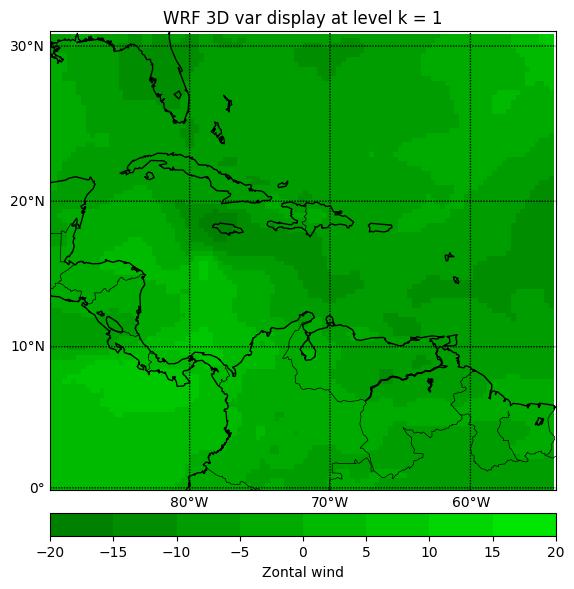

In [67]:
# plot u
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df.U.values)
p3d.plot_shading_world3D(df,u1,ilev=1,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var display",
                             clevs=[-20, -15, -10,-5,0,5,10,15,20],
                             #clevs=[0],
                             minc=(0,0.5,0),maxc=(0,0.9,0),
                             labels="Zontal wind")

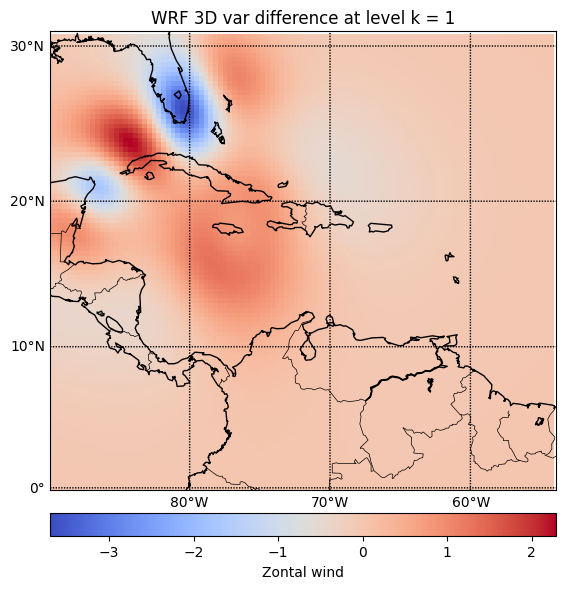

In [61]:
# plot u_new-u_old
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u2 = p3d.shiftU3D(df2.U.values)
p3d.plot_shading_world3D(df,u1-u2,ilev=1,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var difference",
                             #clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             labels="Zontal wind")

<class 'numpy.ndarray'> (30, 150, 150)


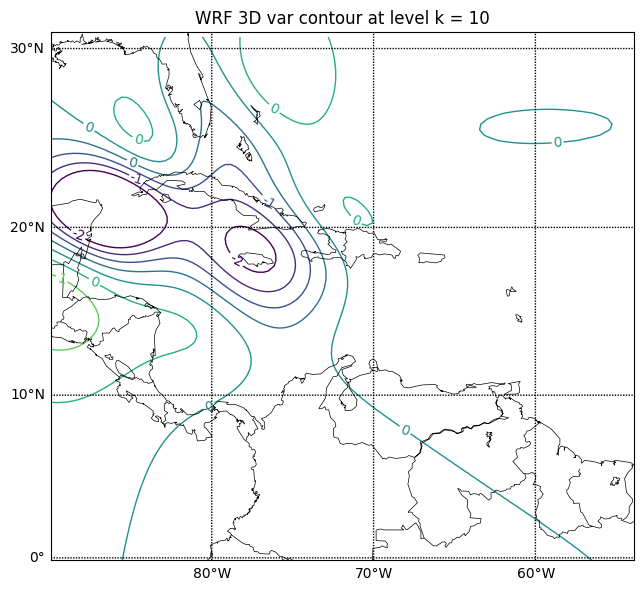

In [57]:
# plot contour u_new-u_old (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df['U'].values)
print(type(u1),u1.shape)
p3d.plot_contour_world3D(df,u1-u2,ilev=10,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var contour",
                             clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             #clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             maplinewidth=0.5)

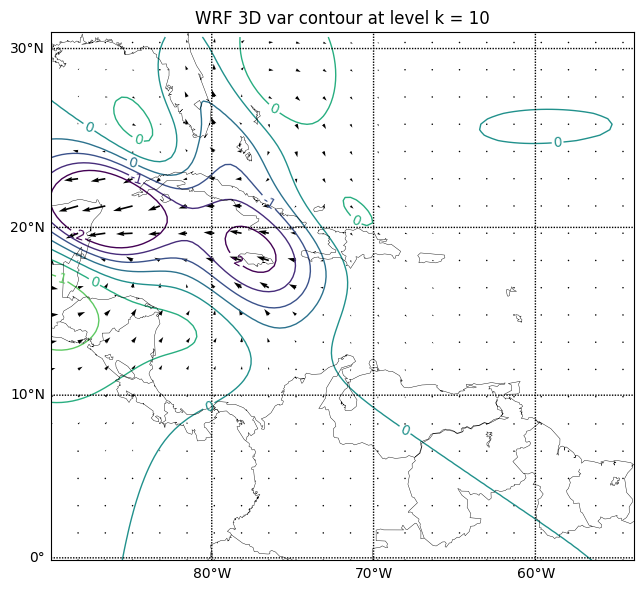

In [70]:
# plot contour u_new-u_old (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df.U.values)
v1 = p3d.shiftV3D(df.V.values)
u2 = p3d.shiftU3D(df2.U.values)
v2 = p3d.shiftV3D(df2.V.values)
p3d.plot_contour_world3Dvector(df,u1-u2,u1-u2,v1-v2,ilev=10,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var contour",
                             clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             #clevs=[0],                             ,
                             scale=100,skipx=5,skipy=5,maplinewidth=0.3)

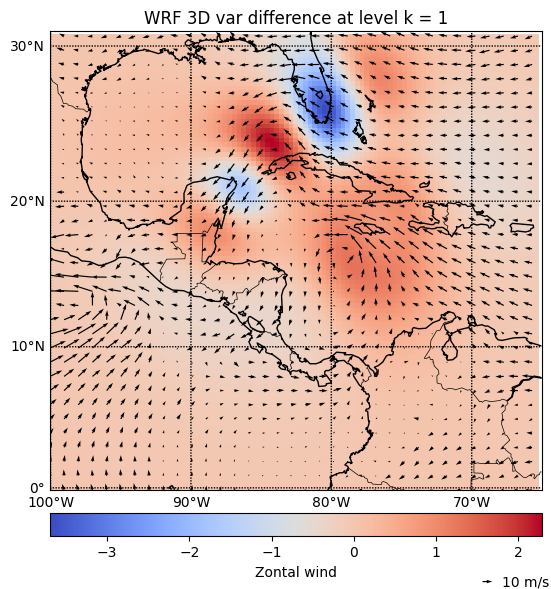

In [59]:
# plot u_new-u_old in shading (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
p3d.plot_shading_world3Dvector(df,u1-u2,ilev=1,
                             slat=0,elat=31,slon=-100,elon=-65,
                             title="WRF 3D var difference",
                             #clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             labels="Zontal wind",scale=500,
                             skipx=3,skipy=3)